In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 26)

In [ ]:
df = pd.read_csv("/content/kidney_disease.csv")
df.head()

In [5]:
df.shape
df.drop('id', axis = 1, inplace = True)

In [6]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [ ]:
df.head()

In [ ]:
df.info()

In [9]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'],errors="coerce")
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'],errors="coerce")
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'],errors="coerce")

In [ ]:
df.info()

In [11]:
##extracting numaric and categorical data

num_cols = [col for col in df.columns if df[col].dtype != 'object']
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [ ]:
num_cols

In [ ]:
#####check unique values in the categorical data

for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

In [14]:
df['diabetes_mellitus'].replace(to_replace={'\tno' :'no' ,'\tyes' :'yes' , ' yes' :'yes'},inplace=True)
df['coronary_artery_disease'].replace(to_replace='\tno' , value='no',inplace=True)
df['class'].replace(to_replace="ckd\t" ,value="ckd",inplace=True)

In [ ]:
for col in cat_cols:
    print(f"{col} has {df[col].unique()} values\n")

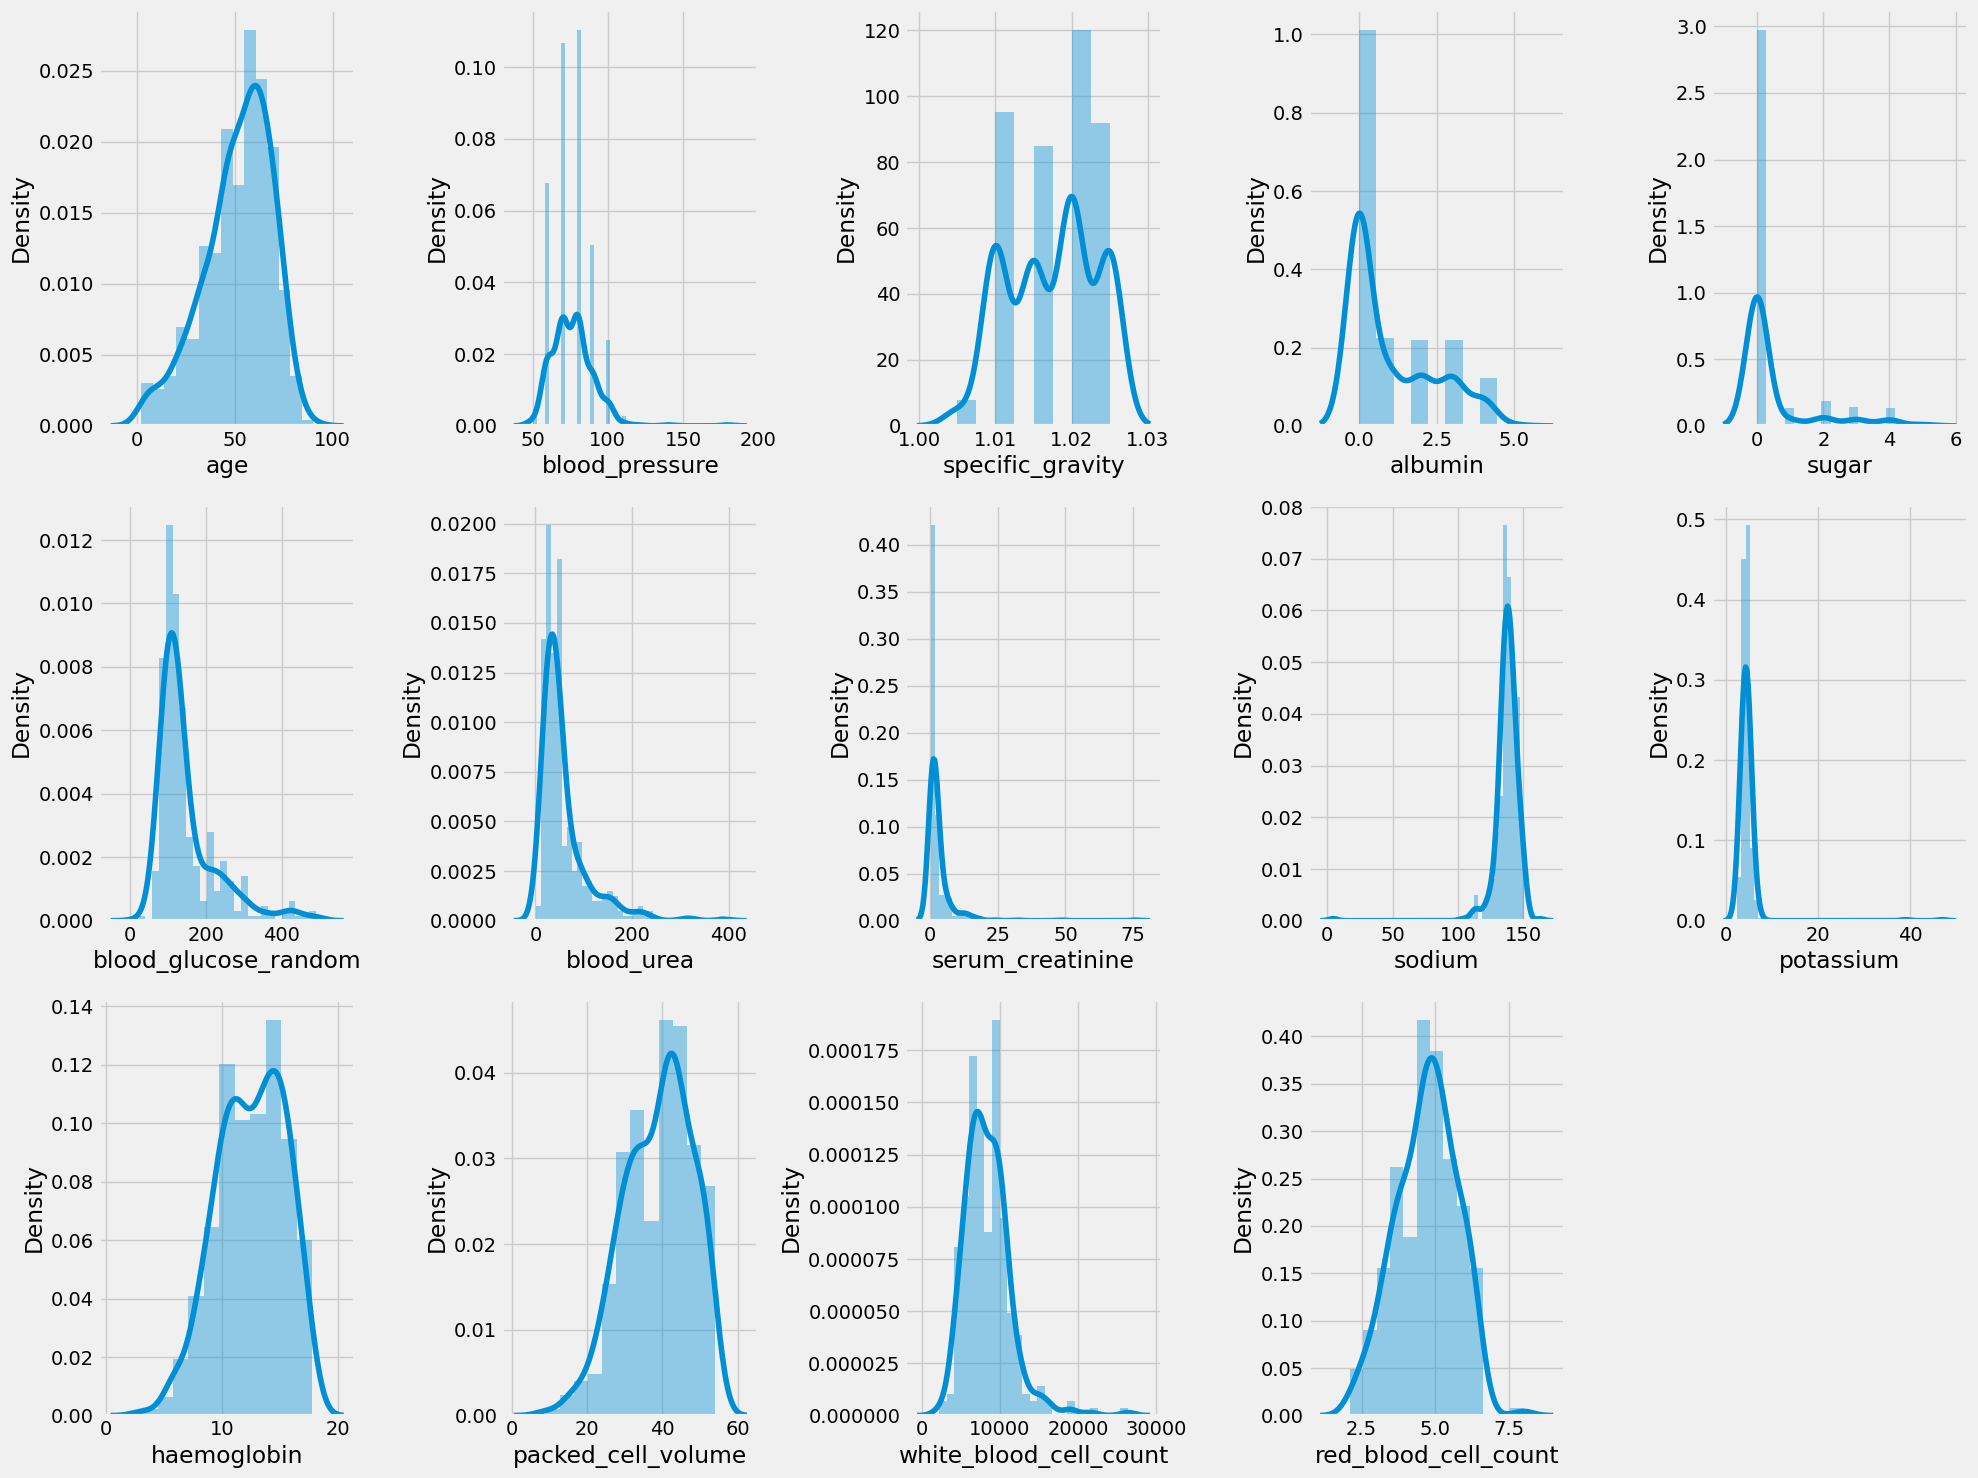

In [16]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [17]:
def handel_outlier(col):
    df[col] =np.log1p(df[col])

In [18]:
handel_outlier('blood_urea')
handel_outlier('sodium')
handel_outlier('potassium')
handel_outlier('serum_creatinine')
handel_outlier('sugar')

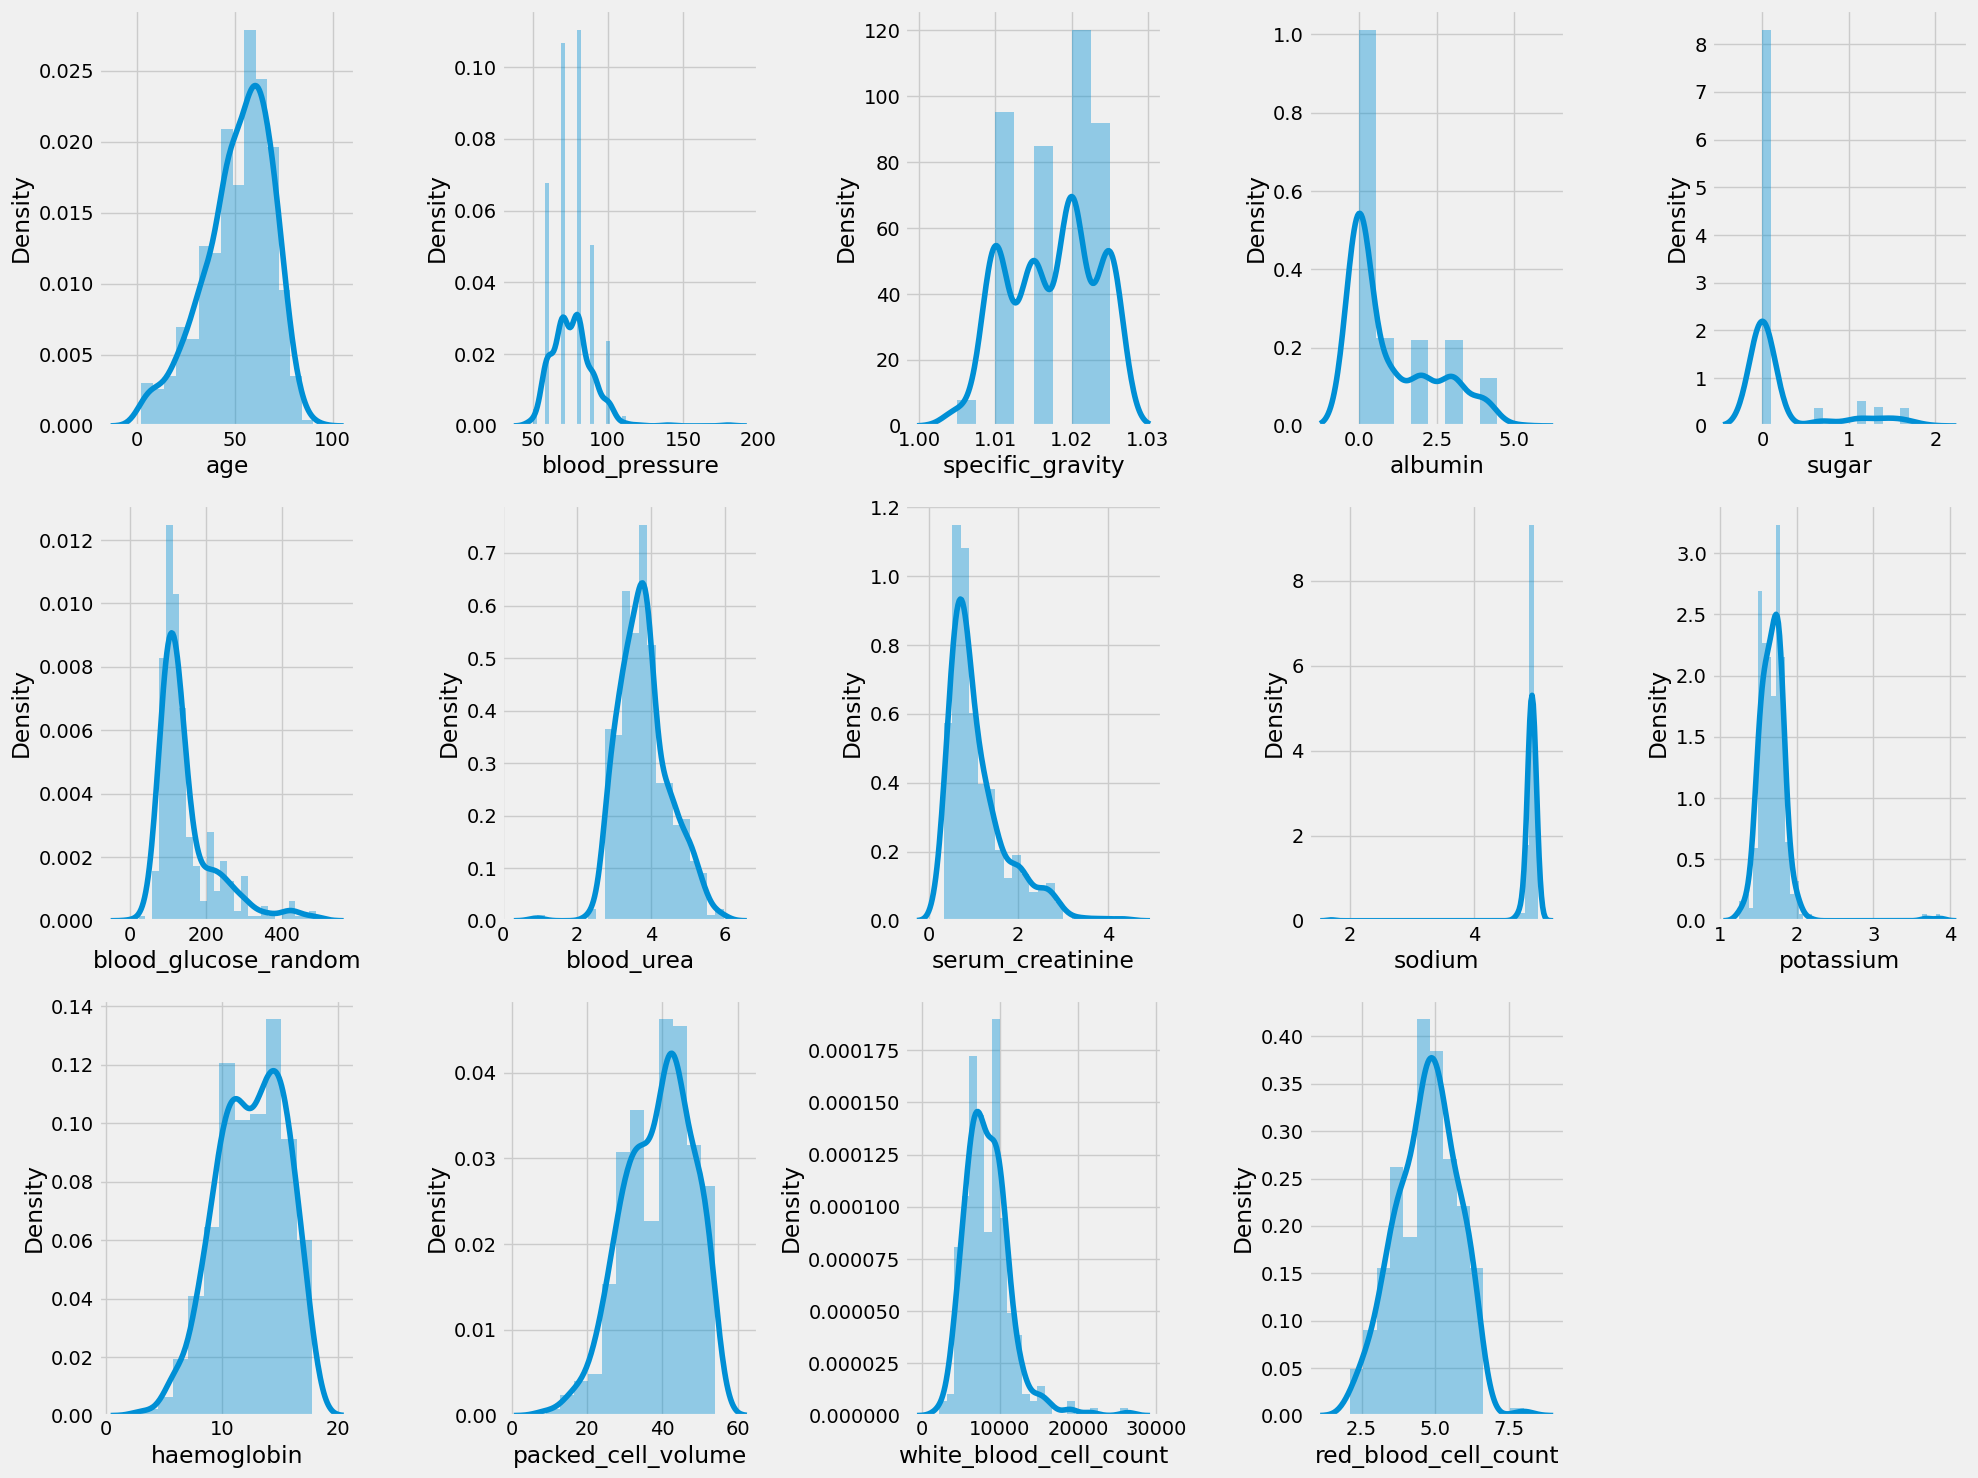

In [19]:

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [20]:
df.isna().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

In [21]:
def random_value_imputation(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(),feature] =random_sample

def impute_mode(feature):
    mode = df[feature].mode()[0]
    df[feature] =df[feature].fillna(mode)

In [22]:

for col in num_cols:
    random_value_imputation(col)

In [23]:
df[num_cols].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [24]:
for col in cat_cols:
    impute_mode(col)

In [25]:
df[cat_cols].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [26]:
from sklearn.preprocessing  import LabelEncoder

encode = LabelEncoder()

for col in cat_cols:
    df[col]=encode.fit_transform(df[col])

In [27]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.000000,1,1,0,0,121.0,3.610918,0.788457,4.997212,1.740466,15.4,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.000000,1,1,0,0,93.0,2.944439,0.587787,4.997212,1.791759,11.3,38.0,6000.0,4.5,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,1.386294,1,1,0,0,423.0,3.988984,1.029619,4.941642,1.686399,9.6,31.0,7500.0,4.9,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.000000,1,0,1,0,117.0,4.043051,1.568616,4.718499,1.252763,11.2,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.000000,1,1,0,0,106.0,3.295837,0.875469,4.948760,1.704748,11.6,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [28]:
X = df.drop(columns ='class' , axis=1)
Y = df['class']

In [29]:
from sklearn.linear_model import Lasso

from sklearn.feature_selection import SelectFromModel

feture_el_model  = SelectFromModel(Lasso(alpha=0.005 ,random_state =42))

feture_el_model.fit(X,Y)
feture_el_model.get_support()

array([ True,  True, False,  True,  True, False, False, False, False,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True])

In [30]:
cols= X.columns
selected_feature = cols[feture_el_model.get_support()]

In [31]:
print('total_features {}' .format(X.shape[1]))
print('total_features {}' .format(len(selected_feature)))

total_features 24
total_features 16


In [32]:
X= X[selected_feature]

In [33]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=.3,random_state=42)

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix ,accuracy_score

models = []
models.append(('LogisticRegression',LogisticRegression(solver='liblinear')))
models.append(('Naive bayes' ,GaussianNB()))
models.append(('RandomForest' ,RandomForestClassifier()))
models.append(('Decision Tree ' ,DecisionTreeClassifier()))
models.append (('KNN' ,KNeighborsClassifier()))

In [35]:
for name , model in models :
    print(name)
    model.fit(x_train , y_train)

    prediction = model.predict(x_test)

    from sklearn.metrics import confusion_matrix

    print(confusion_matrix(prediction,y_test))
    print('\n')
    print(accuracy_score(prediction,y_test))
    print('\n')

LogisticRegression
[[75  1]
 [ 1 43]]


0.9833333333333333


Naive bayes
[[71  2]
 [ 5 42]]


0.9416666666666667


RandomForest
[[76  1]
 [ 0 43]]


0.9916666666666667


Decision Tree 
[[75  1]
 [ 1 43]]


0.9833333333333333


KNN
[[57 19]
 [19 25]]


0.6833333333333333




In [36]:
model = RandomForestClassifier()
print('RandomForest')
model.fit(x_train , y_train)
prediction = model.predict(x_test)
from sklearn.metrics import confusion_matrix

print(confusion_matrix(prediction,y_test))
print('\n')
print(accuracy_score(prediction,y_test))
print('\n')

RandomForest
[[76  1]
 [ 0 43]]


0.9916666666666667


